# Feature Importance Analysis

In this notebook we perform feature analysis on our 3 best models from the previous experiment.

For dataset 1 it can be concluded that the best model for dataset 1 is either our imbalanced or our Logistic Regression model with weighted balancing, for this feature analysis we will use the weighted Logistic Regression model

For dataset 2 it can be concluded that the best model for dataset 2 is either our imbalanced or our Logistic Regression model with weighted balancing, for this feature analysis we will use the weighted Logistic Regression model

For dataset 3 our weighted Logistic Regression model seemed to perform the best on average across our statistics so we will use this model for feature analysis

In [1]:
#All imports needed for this experiment

import pandas as pd
import joblib

import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np


## Helper Functions

In [2]:
feature_name_map = {
    'bp':   'Blood pressure (mm/Hg)',
    'sg':   'Specific gravity of urine',
    'al':   'Albumin in urine',
    'su':   'Sugar in urine',
    'bu':   'Blood urea (mg/dl)',
    'sc':   'Serum creatinine (mg/dl)',
    'sod':  'Sodium level (mEq/L)',
    'pot':  'Potassium level (mEq/L)',
    'hemo': 'Hemoglobin level (gms)',
    'rbc':  'Red blood cell count (millions/cumm)',
    'wc':   'White blood cell count (cells/cumm)',
    'rc':   'Red blood cell count (millions/cumm)',
    'htn':  'Hypertension (yes/no)'
}

In [3]:
def plot_encoded_feature_importance(model, feature_names, title, top_n=15):

    #Get feature importances from model
    importances = np.abs(model.coef_[0])
    
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=feature_importance_df,
        x='importance',
        y='feature',
        hue='feature',
        palette='RdYlGn_r',
        legend=False,
        ax=ax
    )
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Coefficient Magnitude')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Top {top_n} Most Important Features:')
    print('=' * 45)

    rank = 1
    for index, row in feature_importance_df.iterrows():
        print(f'{rank:>2}. {row['feature']:<10s} {row['importance']:.4f}')
        rank +=1

In [4]:
def plot_original_feature_importance(model, numeric_features, title):
    original_importances = {}
    importances = np.abs(model.coef_[0])

    for feat in numeric_features:
        idx = numeric_features.index(feat)
        original_importances[feature_name_map[feat]] = importances[idx]

    orginal_importance_series = pd.Series(original_importances).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    orginal_importance_series.plot(kind='barh', ax=ax, color='#4A90D9')
    ax.set_title(title,
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Total Importance')
    plt.tight_layout()
    plt.show()


## Features For Each Dataset

In [5]:
numeric_features  = joblib.load('..\\models\\numeric_features.joblib')

print("Feature Names Across Datasets: \n")
print("Numeric features:", numeric_features)

Feature Names Across Datasets: 

Numeric features: ['bp', 'sg', 'al', 'su', 'rbc', 'bu', 'sc', 'sod', 'pot', 'hemo', 'wc', 'rc', 'htn']


## Dataset 1 Balanced Logistic Regression Model Feature Analysis

### Load Preprocessor And Models

In [6]:
# Load preprocessor and model for dataset 1
preprocessor = joblib.load('..\\models\\dataset_1\\preprocessor.joblib')
model = joblib.load('..\\models\\dataset_1\\LogisticRegression_weighted.joblib')

### Plot Encoded Feature Importance

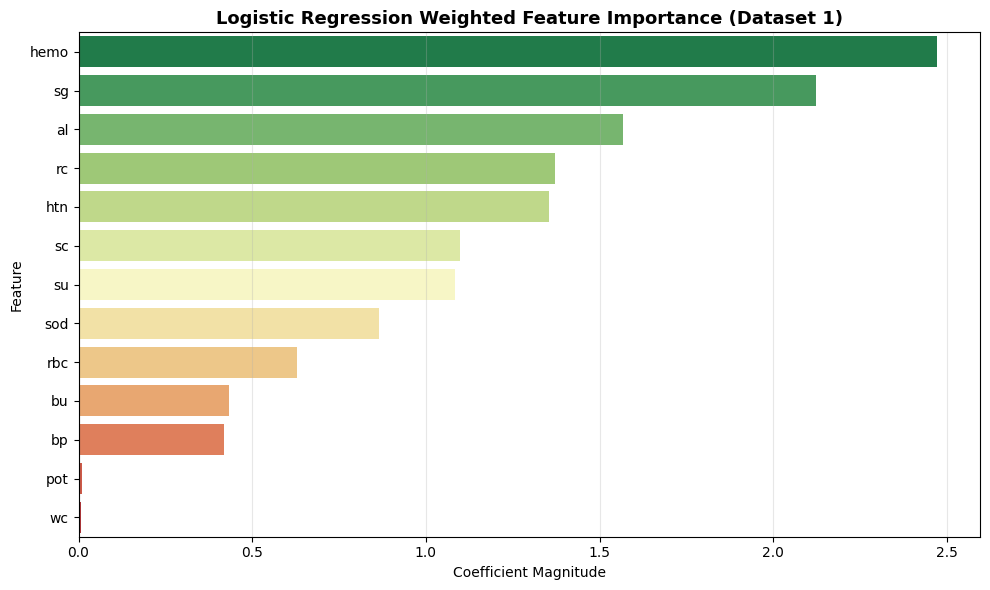

Top 15 Most Important Features:
 1. hemo       2.4713
 2. sg         2.1225
 3. al         1.5681
 4. rc         1.3722
 5. htn        1.3545
 6. sc         1.0986
 7. su         1.0842
 8. sod        0.8640
 9. rbc        0.6275
10. bu         0.4318
11. bp         0.4179
12. pot        0.0095
13. wc         0.0074


In [7]:
plot_encoded_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance (Dataset 1)')

### Plot Original Feature Importance

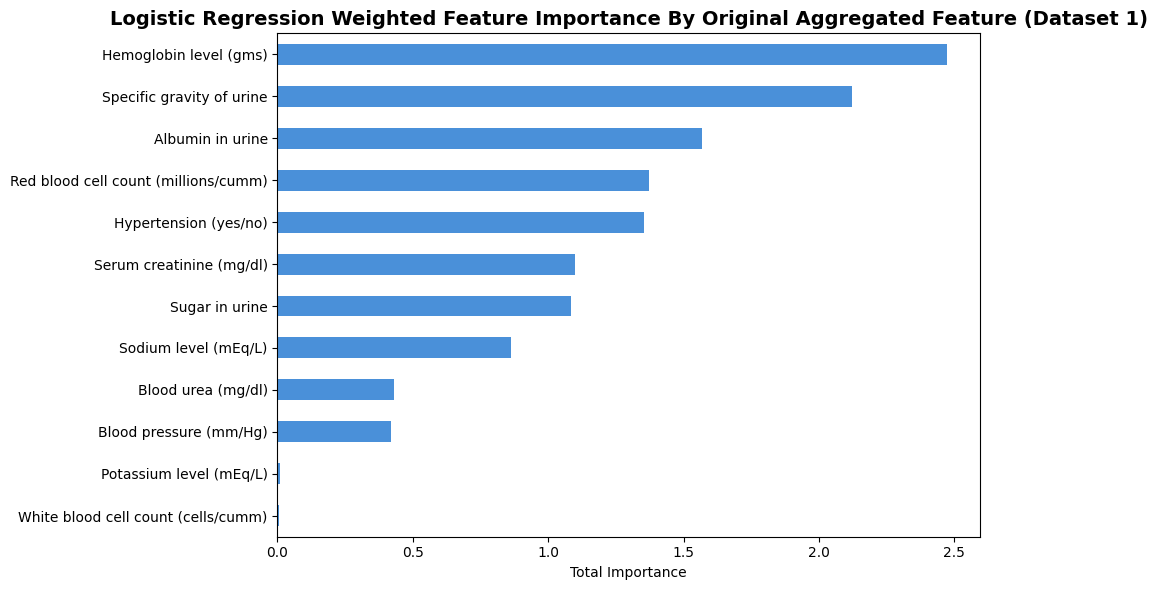

In [8]:
plot_original_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance By Original Aggregated Feature (Dataset 1)')

## Dataset 2 Balanced Logistic Regression Model Feature Analysis

### Load Preprocessor and Models

In [9]:
# Load preprocessor and model for dataset 2
preprocessor = joblib.load('..\\models\\dataset_2\\preprocessor.joblib')
model = joblib.load('..\\models\\dataset_2\\LogisticRegression_weighted.joblib')

### Plot Encoded Feature Importance

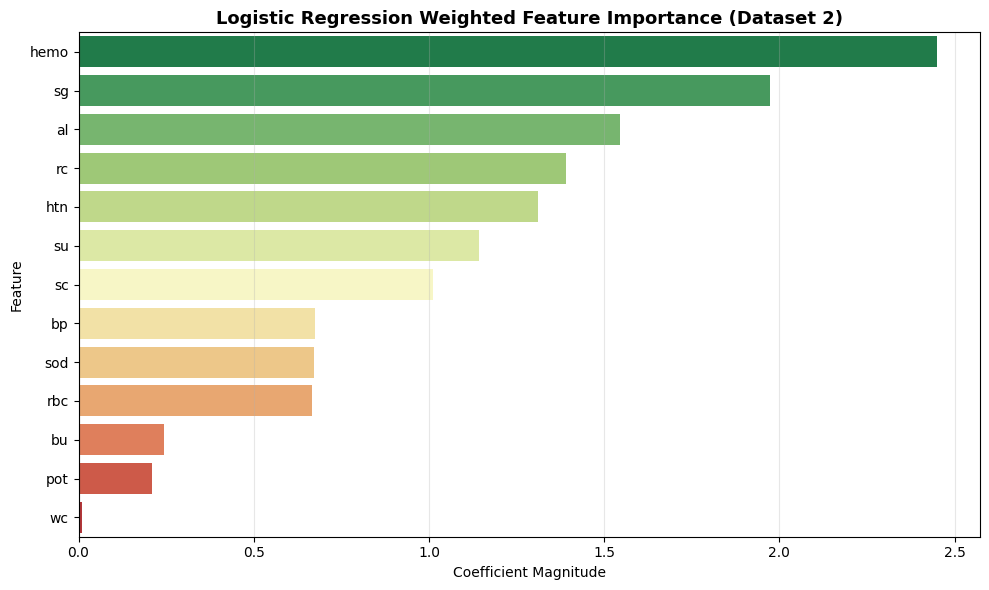

Top 15 Most Important Features:
 1. hemo       2.4499
 2. sg         1.9722
 3. al         1.5439
 4. rc         1.3903
 5. htn        1.3105
 6. su         1.1425
 7. sc         1.0122
 8. bp         0.6749
 9. sod        0.6723
10. rbc        0.6673
11. bu         0.2442
12. pot        0.2085
13. wc         0.0094


In [10]:
plot_encoded_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance (Dataset 2)')

### Plot Original Feature Importance

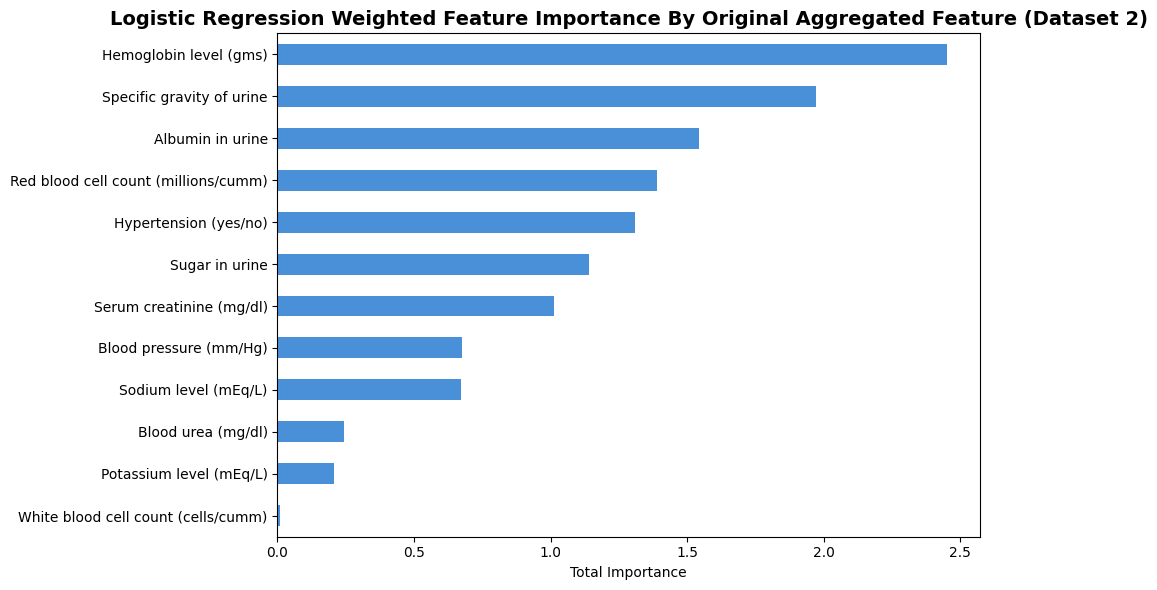

In [11]:
plot_original_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance By Original Aggregated Feature (Dataset 2)')

## Dataset 3 Balanced Logistic Regression Model Feature Analysis

### Load Preprocessor And Models

In [12]:
preprocessor = joblib.load('..\\models\\dataset_3\\preprocessor.joblib')
model = joblib.load('..\\models\\dataset_3\\LogisticRegression_weighted.joblib')

### Plot Encoded Feature Importance

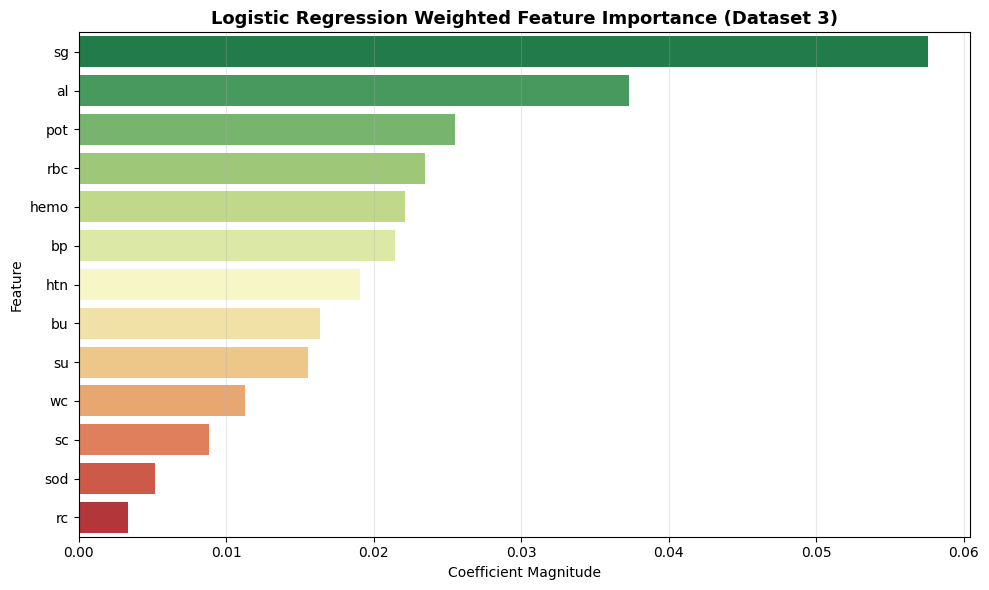

Top 15 Most Important Features:
 1. sg         0.0575
 2. al         0.0373
 3. pot        0.0255
 4. rbc        0.0235
 5. hemo       0.0221
 6. bp         0.0215
 7. htn        0.0191
 8. bu         0.0163
 9. su         0.0156
10. wc         0.0113
11. sc         0.0088
12. sod        0.0052
13. rc         0.0034


In [13]:
plot_encoded_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance (Dataset 3)')

### Plot Original Feature Importance

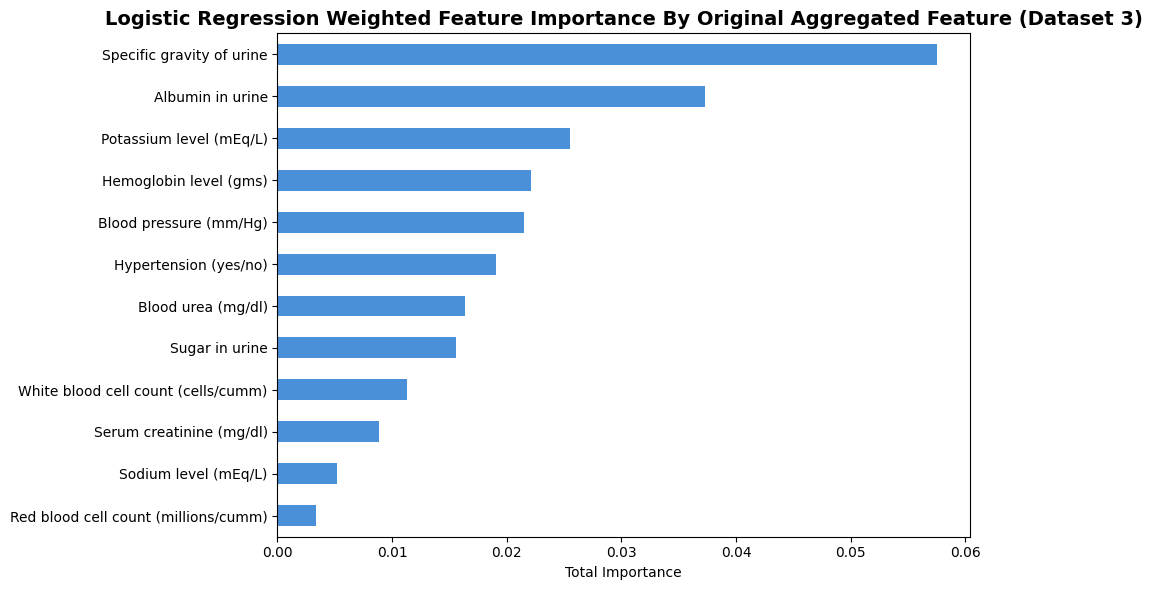

In [14]:
plot_original_feature_importance(model, numeric_features, 'Logistic Regression Weighted Feature Importance By Original Aggregated Feature (Dataset 3)')